In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score
import joblib

In [ ]:
df=sns.load_dataset('titanic')

In [ ]:
print(df.head())

   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  


In [ ]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB
None


In [ ]:
df.isnull().sum()

,0
survived,0
pclass,0
sex,0
age,177
sibsp,0
parch,0
fare,0
embarked,2
class,0
who,0


In [ ]:
median_age=df['age'].describe().loc['50%']
median_age

np.float64(28.0)

In [ ]:
fil_data=df.copy()

In [ ]:
fil_data['age'].isnull().sum()

np.int64(177)

In [ ]:
fil_data['age']=fil_data['age'].fillna(median_age)

In [ ]:
fil_data['embarked'].isnull().sum()

np.int64(2)

In [ ]:
mode_em=fil_data['embarked'].mode()[0]
fil_data['embarked']=fil_data['embarked'].fillna(mode_em)

In [ ]:
fil_data.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [ ]:
fil_data['embarked'].unique()

array(['S', 'C', 'Q'], dtype=object)

In [ ]:
fil_data=fil_data.drop(columns=['deck','embark_town','class','alive','alone'])

In [ ]:
fil_data=fil_data.drop(columns=['adult_male','who'])

In [ ]:
from sklearn.preprocessing import OneHotEncoder
encoder=OneHotEncoder(sparse_output=False).set_output(transform='pandas')
encoded_data=encoder.fit_transform(fil_data[['sex','embarked']])
encoded_data

,sex_female,sex_male,embarked_C,embarked_Q,embarked_S
0,0.0,1.0,0.0,0.0,1.0
1,1.0,0.0,1.0,0.0,0.0
2,1.0,0.0,0.0,0.0,1.0
3,1.0,0.0,0.0,0.0,1.0
4,0.0,1.0,0.0,0.0,1.0
...,...,...,...,...,...
886,0.0,1.0,0.0,0.0,1.0
887,1.0,0.0,0.0,0.0,1.0
888,1.0,0.0,0.0,0.0,1.0
889,0.0,1.0,1.0,0.0,0.0


In [ ]:
fil_data=fil_data.drop(columns=['sex','embarked'])

In [ ]:
fil_data = pd.concat([fil_data,encoded_data],axis=1)
fil_data.head()

,survived,pclass,age,sibsp,parch,fare,sex_female,sex_male,embarked_C,embarked_Q,embarked_S
0,0,3,22.0,1,0,7.2500,0.0,1.0,0.0,0.0,1.0
1,1,1,38.0,1,0,71.2833,1.0,0.0,1.0,0.0,0.0
2,1,3,26.0,0,0,7.9250,1.0,0.0,0.0,0.0,1.0
3,1,1,35.0,1,0,53.1000,1.0,0.0,0.0,0.0,1.0
4,0,3,35.0,0,0,8.0500,0.0,1.0,0.0,0.0,1.0


In [ ]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler().set_output(transform="pandas")
scaled_data=scaler.fit_transform(fil_data[['age','fare']])
scaled_data

,age,fare
0,-0.565736,-0.502445
1,0.663861,0.786845
2,-0.258337,-0.488854
3,0.433312,0.420730
4,0.433312,-0.486337
...,...,...
886,-0.181487,-0.386671
887,-0.796286,-0.044381
888,-0.104637,-0.176263
889,-0.258337,-0.044381


In [ ]:
fil_data=fil_data.drop(columns=['age','fare'])

In [ ]:
fil_data=pd.concat([fil_data,scaled_data],axis=1)

In [ ]:
fil_data.head()

,survived,pclass,sibsp,parch,sex_female,sex_male,embarked_C,embarked_Q,embarked_S,age,fare
0,0,3,1,0,0.0,1.0,0.0,0.0,1.0,-0.565736,-0.502445
1,1,1,1,0,1.0,0.0,1.0,0.0,0.0,0.663861,0.786845
2,1,3,0,0,1.0,0.0,0.0,0.0,1.0,-0.258337,-0.488854
3,1,1,1,0,1.0,0.0,0.0,0.0,1.0,0.433312,0.420730
4,0,3,0,0,0.0,1.0,0.0,0.0,1.0,0.433312,-0.486337


In [ ]:
x_train,x_test,y_train,y_test=train_test_split(fil_data.drop(columns='survived'),fil_data['survived'],test_size=0.2,random_state=42)

In [ ]:
models={
    "logisticregression":LogisticRegression(max_iter=6000),
    "decisiontreeregressor":DecisionTreeClassifier(),
    "randomforest":RandomForestClassifier(),
    "svm":SVC()

}

In [ ]:
results=[]
for name , model in models.items():
    model.fit(x_train,y_train)
    y_pred=model.predict(x_test)
    accuracy=accuracy_score(y_test,y_pred)
    precision=precision_score(y_test,y_pred)
    recall=recall_score(y_test,y_pred)
    f1=f1_score(y_test,y_pred)
    results.append([name,accuracy,precision,recall,f1])

In [ ]:
comparision_df=pd.DataFrame(results,columns=['models','accuracy','preision','recall','f1'])
comparision_df

,models,accuracy,preision,recall,f1
0,logisticregression,0.810056,0.785714,0.743243,0.763889
1,decisiontreeregressor,0.787709,0.743243,0.743243,0.743243
2,randomforest,0.810056,0.770270,0.770270,0.770270
3,svm,0.815642,0.805970,0.729730,0.765957


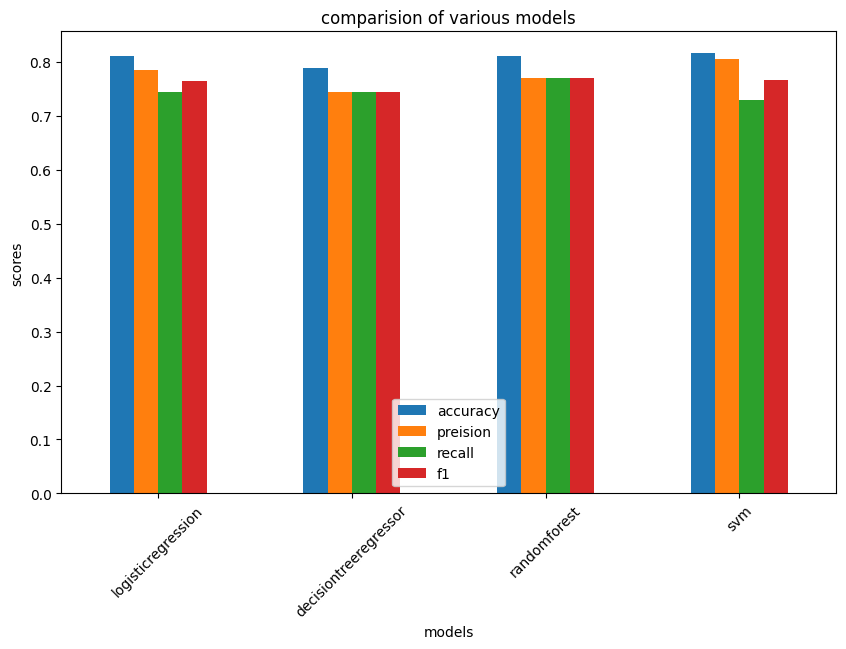

In [ ]:
comparision_df.set_index("models")[['accuracy','preision','recall','f1']].plot(kind='bar',figsize=(10,6))
plt.title("comparision of various models")
plt.xlabel("models")
plt.ylabel("scores")
plt.xticks(rotation=45)
plt.show()

In [ ]:
for name,model in models.items():
   train_score=model.score(x_train,y_train)
   test_score=model.score(x_test,y_test)
   print(f"{name} train score: {train_score}")
   print(f"{name} test score: {test_score}")
   print("-"*50)

logisticregression train score: 0.800561797752809
logisticregression test score: 0.8100558659217877
--------------------------------------------------
decisiontreeregressor train score: 0.9789325842696629
decisiontreeregressor test score: 0.7877094972067039
--------------------------------------------------
randomforest train score: 0.9789325842696629
randomforest test score: 0.8100558659217877
--------------------------------------------------
svm train score: 0.8356741573033708
svm test score: 0.8156424581005587
--------------------------------------------------


In [ ]:
best_model_name = comparision_df.sort_values(by="f1", ascending=False).iloc[0]["models"]

best_model = models[best_model_name]

joblib.dump(best_model, "best_model.pkl")

print("Best Model Saved:", best_model_name)

Best Model Saved: randomforest
